# Derving Cart + Pendulum dynamics with sympy

This notebook shows how we can use sympy to follow along to the derivation of the dynamics of a pendulum on a cart connected to a string. This follows both the derivation here: https://www.myphysicslab.com/pendulum/cart-pendulum-en.html and https://www.youtube.com/watch?v=SZdZeT93C1s&list=PLkdGijFCNuVnMsuC4uFncWusSA9aUzzIp&index=7 for help.

This works as follows. We define all the variables we need for our system. Define the energy of our system, calculate the Lagrangian and use the Euler-Langrangian equation to find the equation of motion

Ref:

[1] https://www.youtube.com/watch?v=ENNyltVTJaE&list=PLkdGijFCNuVnMsuC4uFncWusSA9aUzzIp&index=4

[2] https://www.youtube.com/watch?v=SZdZeT93C1s&list=PLkdGijFCNuVnMsuC4uFncWusSA9aUzzIp&index=7

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from matplotlib import animation
from matplotlib.animation import PillowWriter

## Constants

Define basic constants of our system, and function of our system

In [2]:
t, R, M, m, g, d, b, k = sp.symbols(r't R M m g \delta b k')

In [3]:
the, x = sp.symbols(r'\theta x', cls=sp.Function)

the = the(t)
the_d = sp.diff(the, t)
the_dd = sp.diff(the_d, t)

x = x(t)
x_d = sp.diff(x, t)
x_dd = sp.diff(x_d, t)

In [4]:
xb, yb = sp.symbols('x y', cls=sp.Function)

In [5]:
# For nicer formatting
omega, v, a, _odot = sp.symbols(r'\dot{\theta} \dot{x} \ddot{x} \ddot{\theta}')
omega, v, a, _odot = sp.symbols(r'\omega \dot{x} \ddot{x} \dot{\omega}')
subs = {the_d: omega, x_d: v, x_dd: a, the_dd: _odot}

In [6]:
xb = x + R * sp.sin(the)
yb =   - R * sp.cos(the)

xb_d = sp.diff(xb, t)
xb_dd = sp.diff(xb_d, t)

yb_d = sp.diff(yb, t)
yb_dd = sp.diff(yb_d, t)

In [7]:
xb_f = sp.lambdify((x, the, R), xb)
yb_f = sp.lambdify((x, the, R), yb)

def get_coords(x, the, R):
    return (
        x, np.zeros(x.shape),
        xb_f(x, the, R), yb_f(x, the, R)
    )

## Calcaulte the energy of the system

Now calculate the kinetic energy T and potential engery V of the system

In [8]:
T = 1 / 2 * M * x_d ** 2 + 1 / 2 * m * (xb_d ** 2 + yb_d ** 2)

In [9]:
T.subs(subs)

0.5*M*\dot{x}**2 + 0.5*m*(R**2*\omega**2*sin(\theta(t))**2 + (R*\omega*cos(\theta(t)) + \dot{x})**2)

In [10]:
y_ground = R - R * sp.cos(the)
y_ground_f = sp.lambdify(the, y_ground)
# y_ground_f(0), y_ground_f(np.pi)

In [11]:
V = m * g * y_ground + 1 / 2 * k * x**2
V

g*m*(-R*cos(\theta(t)) + R) + 0.5*k*x(t)**2

## Lagrangian

Now time to calcualte the Lagrangian of our system $L = T - V$

In [12]:
L = T - V

In [13]:
L.subs(subs)

0.5*M*\dot{x}**2 - g*m*(-R*cos(\theta(t)) + R) - 0.5*k*x(t)**2 + 0.5*m*(R**2*\omega**2*sin(\theta(t))**2 + (R*\omega*cos(\theta(t)) + \dot{x})**2)

## Compute Lagrangian Equations

$LE_x = \frac{d}{dt}(\frac{\partial L}{\partial \dot x}) - \frac{\partial L}{\partial x} = 0$

to derive the equation of motion of the cart and pendulum.

To deal with the frictional force on the cart we define $LE_x = -\delta x$

So define $W_x = LE_x + \delta x = 0$


In [14]:
LE_x = sp.diff(sp.diff(L, x_d), t) - sp.diff(L, x)
LE_x = LE_x.simplify()
LE_x.subs(subs)

1.0*M*\ddot{x} + 1.0*k*x(t) + 1.0*m*(R*\dot{\omega}*cos(\theta(t)) - R*\omega**2*sin(\theta(t)) + \ddot{x})

In [15]:
W_x = ( LE_x + d * x_d ).simplify()
W_x

1.0*M*Derivative(x(t), (t, 2)) + \delta*Derivative(x(t), t) + 1.0*k*x(t) + 1.0*m*(-R*sin(\theta(t))*Derivative(\theta(t), t)**2 + R*cos(\theta(t))*Derivative(\theta(t), (t, 2)) + Derivative(x(t), (t, 2)))

This is linear in $\ddot x$ so we can solve for the equation of motion in the x direction

In [16]:
sp.solve(W_x, x_dd)[0].subs(subs)

(-R*\dot{\omega}*m*cos(\theta(t)) + R*\omega**2*m*sin(\theta(t)) - \delta*\dot{x} - k*x(t))/(M + m)

In [17]:
LE_the = sp.diff(sp.diff(L, the_d), t) - sp.diff(L, the)

In [18]:
W_the = LE_the + b * the_d

In [19]:
W_the.simplify().subs(subs)

1.0*R**2*\dot{\omega}*m + 1.0*R*\ddot{x}*m*cos(\theta(t)) + 1.0*R*g*m*sin(\theta(t)) + 1.0*\omega*b

In [20]:
sp.solve(W_the, the_dd)[0].subs(subs).simplify()

-\ddot{x}*cos(\theta(t))/R - g*sin(\theta(t))/R - \omega*b/(R**2*m)

## Numberical solution and simulation

We have $\ddot x$ and $\ddot \theta$ but in order to use the odeint we need to solve them in in terms of lower derivates variables

$\ddot x = f(x, \dot x, \theta, \dot \theta)$

$\ddot \theta = g(x, \dot x, \theta, \dot \theta)$

since we have two linear systems of equations in $W_x$ and $W_the$ we can solve for $\ddot x$ and $\ddot \theta$

Now we turn these expressions into numpy functions $f$

$S = \begin{bmatrix}
x \\
\dot x \\
\theta \\
\dot \theta \\
\end{bmatrix} = \begin{bmatrix}
x \\
v \\
\theta \\
\omega
\end{bmatrix}$ and so  $dS = \begin{bmatrix}
\dot x \\
\ddot x \\
\dot \theta \\
\ddot \theta
\end{bmatrix} = \begin{bmatrix}
v \\
\dot v \\
\omega \\
\dot \omega
\end{bmatrix} = f(S)$


In [21]:
sols = sp.solve([W_x, W_the], [x_dd, the_dd])

In [22]:
vdot = sols[x_dd].simplify()
vdot.subs(subs)

(R**2*\omega**2*m*sin(\theta(t)) - R*\delta*\dot{x} + R*g*m*sin(2*\theta(t))/2 - R*k*x(t) + \omega*b*cos(\theta(t)))/(R*(M + m*sin(\theta(t))**2))

In [23]:
odot = sols[the_dd].simplify()
odot.subs(subs).simplify()

(-M*R*g*m*sin(\theta(t)) - M*\omega*b - R**2*\omega**2*m**2*sin(2*\theta(t))/2 + R*\delta*\dot{x}*m*cos(\theta(t)) - R*g*m**2*sin(\theta(t)) + R*k*m*x(t)*cos(\theta(t)) - \omega*b*m)/(R**2*m*(M + m*sin(\theta(t))**2))

The above equation match https://www.myphysicslab.com/pendulum/cart-pendulum-en.html

In [24]:
S = sp.Matrix([
    x,
    x_d,
    the,
    the_d
])
S

Matrix([
[                    x(t)],
[     Derivative(x(t), t)],
[               \theta(t)],
[Derivative(\theta(t), t)]])

In [25]:
f = sp.Matrix([
    x_d,
    sols[x_dd],
    the_d,
    sols[the_dd],
])
f.simplify()
f

Matrix([
[                                                                                                                                                                                                                                                                        Derivative(x(t), t)],
[                                                                                         (R**2*m*sin(\theta(t))*Derivative(\theta(t), t)**2 - R*\delta*Derivative(x(t), t) + R*g*m*sin(2*\theta(t))/2 - R*k*x(t) + b*cos(\theta(t))*Derivative(\theta(t), t))/(R*(M + m*sin(\theta(t))**2))],
[                                                                                                                                                                                                                                                                   Derivative(\theta(t), t)],
[(-M*R*g*m*sin(\theta(t)) - M*b*Derivative(\theta(t), t) - R**2*m**2*sin(2*\theta(t))*Derivative(\theta(t), t)**2/2 + R*\delta*m*c

In [26]:
values = {R: 1, m: 1, M: 1, g: 9.80, b: 0, d: 10, k: 3}

In [27]:
f_lambda = sp.lambdify(list(S), f.subs(values))

In [28]:
def dSdt(S, t):
    return f_lambda(*S).T[0]

## Simulation

Now we want to animatet the cart + pend with a simple line with one end the cart - the other bob


In [29]:
t = np.linspace(0, 10, 1000)
y0 = [0.9, 0, np.pi / 2, 0]
ans = odeint(dSdt, y0=y0, t=t)
cart_x, cart_y, pend_x, pend_y = get_coords(ans.T[0], ans.T[2], values[R])

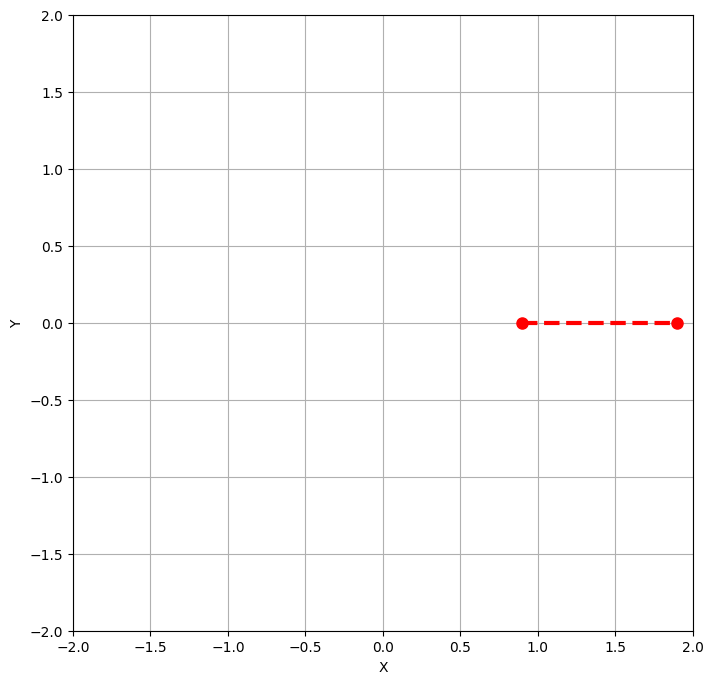

In [30]:
def animate(i):
    ln1.set_data([cart_x[i], pend_x[i]], [cart_y[i], pend_y[i]])

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.grid()
ln1, = plt.plot([], [], 'ro--', lw=3, markersize=8)
ax.set_ylim(-2, 2)
ax.set_xlim(-2,2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ani = animation.FuncAnimation(fig, animate, frames=1000, interval=50)
ani.save('cart-pendulum.gif',writer='pillow',fps=50)